# Le Vietnam : un regard croisé entre France et États-Unis

Code de la première partie : thèses françaises et américaines

Auteurs : Thomas Ben Yazza, Noam Chabot, Solène Gros, Sacha Levi Mazloum et Lazar van Berchem

# 1. Import des bibliothèques et des données

In [75]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
from tqdm import tqdm
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
from collections import Counter
import networkx as nx

Note : les deux jeux de données ici présents ont déjà été complétés par le code qui suit. Cela permet de ne pas avoir à relancer deux boucles qui prennent chacune environ une demi-heure, même si cette étape peut tout à fait être refaite.

In [76]:
df_eng = pd.read_csv("theses_anglaises.csv")
print(len(df_eng))
display(df_eng.head(5))

df_fr = pd.read_csv("theses_fr_abstrat.csv", sep = ',')
print(len(df_fr))
df_fr.head(5)

2507


,Title,Abstract,StoreId,AccessionNumber,ArticleType,Authors,copyright,documentType,entryDate,isbn,...,coden,correspondenceAuthor,issn,issue,originalTitle,volume,companies,digitalObjectIdentifier,institutions_countries,is_us
0,The treatment of post-traumatic stress disorde...,This investigation explored the reliving exper...,42458642,90870,Dissertations & Theses,"Wilde, Andrea Laura",NaN,Doctoral Dissertation,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan
1,Investigation of post-traumatic stress reactio...,PTSD has only recently been categorized by psy...,42457540,90677,Dissertations & Theses,"Capichioni, Walter",NaN,Doctoral Dissertation,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan
2,Psychological testing and posttraumatic stress...,This study focused on the possible utility of ...,42453446,90766,Dissertations & Theses,"Magoni, Kimball Scott",NaN,Doctoral Dissertation,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan
3,Perceptual avoidance in Vietnam combat veteran...,Four operationally-defined measures of percept...,42453174,90680,Dissertations & Theses,"Carnevale, George Joseph",NaN,Doctoral Dissertation,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan
4,The impact of the Vietnam war on current indiv...,Chronic or delayed PTSDs have received increas...,42453112,90776,Dissertations & Theses,"Miles, Wilbert L",NaN,Doctoral Dissertation,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan


1070


,NNT,NumSujet,Auteurs,Titre FR,Titre EN,Directeurs,Discipline,Date de soutenance,Date de première inscription,Etablissement de soutenance,...,Président du jury,Rapporteurs,Examinateurs,Mots clés FR,Mots clés EN,Langue,Source,Statut,Accessible,Abstract_EN
0,2015TOU10010,NaN,"Nguyen, Linh Giang (187515689)",La protection constitutionnelle des droits de ...,Constitutional protection of Human rights in V...,"Crouzatier, Jean-Marie (028815726) || Vo, Khan...",Droit public,29/06/2015,NaN,Toulouse 1 (026404354),...,NaN,NaN,NaN,Constitutions -- Vietnam || Recours constituti...,NaN,fr,star,soutenue,oui,The Constitution definitely has an indispensab...
1,2010PA131016,NaN,"Nguyen, Binh Duong (151022720)",Stratégie industrielle des pays asiatiques en ...,Industrial Strategy of the Asian countries in ...,"Mazier, Jacques (027020649)",Sciences économiques,01/01/2010,NaN,Paris 13 (02640463X),...,NaN,NaN,NaN,Développement durable || Planification stratég...,NaN,fr,sudoc,soutenue,oui,This thesis examines the key issues in choosin...
2,2009PA020093,NaN,"Pham, Viet Anh (142793787)",L' implantation et l'activité des sociétés étr...,The establishment and the operation of foreign...,"Khairallah, Georges (060563834)",Droit international,01/01/2009,NaN,Paris 2 (026403145),...,NaN,NaN,NaN,Conditions économiques -- Vietnam -- 1986-.......,NaN,fr,sudoc,soutenue,non,NaN
3,2024INAL0005,NaN,"Lê, Antoine (28231234X)",La recherche politique d'une autonomie stratég...,The political quest for strategic autonomy. Th...,"Tréglodé, Benoît de (060369531) || Hardy, Andr...","Histoire, sociétés et civilisatons",30/05/2024,NaN,"Paris, INALCO (026388715)",...,NaN,"Goscha, Christopher E. (059073160) || Journoud...","Đoàn, Cầm Thi (053495055) || Dullin, Sabine (0...",Viet-Nam (République) || Vietnam -- 1945-1975 ...,Vietnam War || Vietnamese Communist Party || S...,fr,star,soutenue,oui,Much has been written about the relationship b...
4,2005PA090058,NaN,"Nguyen, Duc Tho (116118571)",Investissement direct étranger au Vietnam,Foreign direct investment in Vietnam,"Métais, Joël (028176030)",Sciences économiques,01/01/2005,NaN,Paris 9 (027787109),...,NaN,NaN,NaN,Relations économiques extérieures || Développe...,NaN,fr,sudoc,soutenue,oui,NaN


# 2. Manipulation des données

## 2.1 Séparation des données américaines parmi les données en langue anglaise

In [77]:
def get_author_countries(name):
    r = requests.get("https://api.openalex.org/authors",params={"search": name, "per-page": 3}).json()

    if not r.get("results"):
        return None

    author = r["results"][0]
    countries = set()

    affiliations = author.get("affiliations") or []
    for aff in affiliations:
        institution = aff.get("institution", {})
        country_code = institution.get("country_code")
        if country_code:
            countries.add(country_code)
    return "|".join(sorted(countries)) if countries else None

In [78]:
get_author_countries("Jonsson, Kristina") # simple exemple

'SE|ZM'

Comme dit précédemment les jeux de données contiennent déjà le produit du scraping, donc pas besoin de lancer la cellule ci-dessous.

In [79]:
'''

institutions_countries = []
for guy in tqdm(df_eng["Authors"]) :
    institutions_countries.append(get_author_countries(guy))

df_eng["instituions_countries"] = institutions_countries

'''

'\n\ninstitutions_countries = []\nfor guy in tqdm(df_eng["Authors"]) :\n    institutions_countries.append(get_author_countries(guy))\n\ndf_eng["instituions_countries"] = institutions_countries\n\n'

In [80]:
df_eng["institutions_countries"] = df_eng["institutions_countries"].fillna(value=np.nan)

In [81]:
df_eng['is_us'].value_counts()

is_us
Nan      1288
True      988
False     231
Name: count, dtype: int64

In [82]:
df_eng = df_eng[df_eng['is_us'] == "True"]

df_eng['is_us'].value_counts()

is_us
True    988
Name: count, dtype: int64

## 2.2 Scraping des abstracts des thèses françaises

In [83]:
tqdm.pandas()

def get_abstract_en_from_nnt(nnt):
    url = f"https://theses.fr/{nnt}.xml"
    r = requests.get(url)
    time.sleep(1)

    if r.status_code != 200:
        return None

    soup = BeautifulSoup(r.content, "xml")

    # chercher abstract en anglais
    abstract_en = soup.find(
        lambda tag: tag.name == "abstract"
        and tag.get("xml:lang") in ["en", "eng"]
    )

    if abstract_en:
        return abstract_en.get_text(strip=True)
    else:
        return None

#df_fr["Abstract_EN"] = df_fr["NNT"].progress_apply(get_abstract_en_from_nnt) # de même, celle cellule prendra une demi-heure à tourner mais les données sont déjà là

## 2.3 Regroupement des deux jeux de données

In [84]:
df_fr_clean = (
    df_fr[
        ['Titre EN', 'Auteurs', 'Abstract_EN', 'Date de soutenance']
    ]
    .rename(columns={
        'Titre EN': 'title',
        'Auteurs': 'authors',
        'Abstract_EN': 'abstract',
        'Date de soutenance': 'date'
    })
)
# Ajouter la colonne 'source'
df_fr_clean['source'] = 'fr'

df_eng_clean = (
    df_eng[
        ['Title', 'Authors', 'Abstract', 'year']
    ]
    .rename(columns={
        'Title': 'title',
        'Authors': 'authors',
        'Abstract': 'abstract',
        'year': 'date'
    })
)
# Ajouter la colonne 'source'
df_eng_clean['source'] = 'us'

# Concaténer les deux DataFrames
df = pd.concat([df_fr_clean, df_eng_clean], ignore_index=True)

df

,title,authors,abstract,date,source
0,Constitutional protection of Human rights in V...,"Nguyen, Linh Giang (187515689)",The Constitution definitely has an indispensab...,29/06/2015,fr
1,Industrial Strategy of the Asian countries in ...,"Nguyen, Binh Duong (151022720)",This thesis examines the key issues in choosin...,01/01/2010,fr
2,The establishment and the operation of foreign...,"Pham, Viet Anh (142793787)",NaN,01/01/2009,fr
3,The political quest for strategic autonomy. Th...,"Lê, Antoine (28231234X)",Much has been written about the relationship b...,30/05/2024,fr
4,Foreign direct investment in Vietnam,"Nguyen, Duc Tho (116118571)",NaN,01/01/2005,fr
...,...,...,...,...,...
2053,The Tay So'n Uprising: Society and rebellion i...,"Dutton, George Edson",This project is an examination of the [special...,2001,us
2054,Ambiguity of identity: The case of Na Mieu in ...,"Thang, Nguyen Van",This dissertation is a study of how people in ...,2001,us
2055,Missions and conversions: Creating the Montagn...,"Pearson, Thomas",This dissertation examines the history of cros...,2001,us
2056,Employment in Vietnam: A gender equal division...,"Alva, Soumya",As developing economies undergo far reaching m...,2001,us


In [85]:
df['abstract'] = df['abstract'].fillna(df['title']) # pour les rares qui n'ont pas d'abstract, on prend le titre à la place 
df = df.dropna(subset=['abstract']) 

## 2.4 Graphiques descriptifs

In [86]:
df['year'] = pd.to_numeric(df['date'].astype(str).str[-4:], errors='coerce')
df = df[df['year'] > 1985]

year_source_counts = df.groupby(['year', 'source']).size().unstack(fill_value=0)

C:\Users\lvber\AppData\Local\Temp\ipykernel_13416\2331406465.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = pd.to_numeric(df['date'].astype(str).str[-4:], errors='coerce')


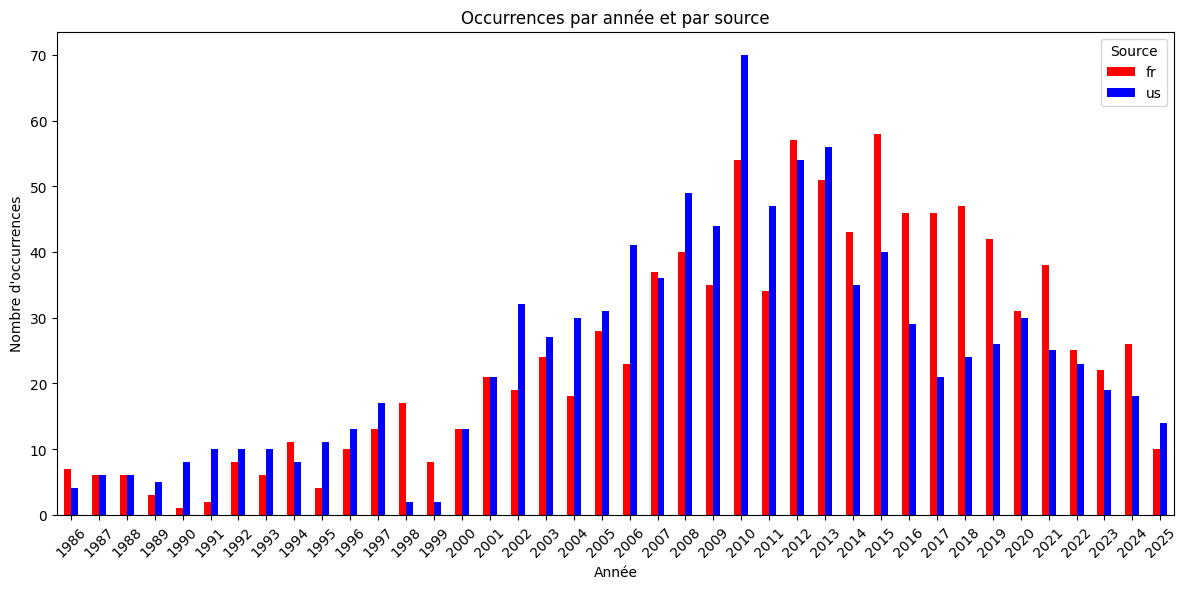

In [87]:
year_source_counts.plot(
    kind='bar',
    stacked=False,    
    figsize=(12,6),
    color=['red', 'blue']
)
plt.xlabel("Année")
plt.ylabel("Nombre d'occurrences")
plt.title("Occurrences par année et par source")
plt.xticks(rotation=45)
plt.legend(title="Source")
plt.tight_layout()
plt.savefig("année.png")
plt.show()

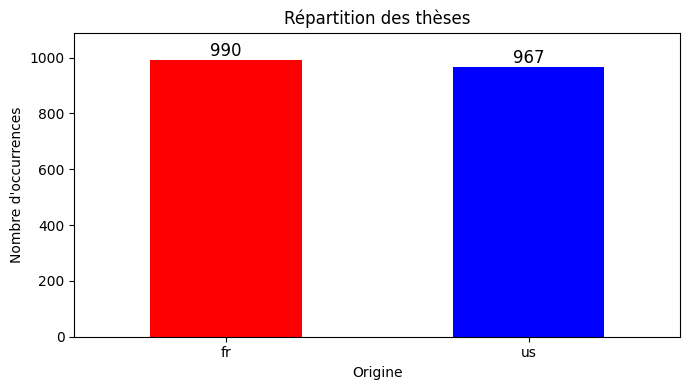

In [88]:
source_counts = df['source'].value_counts()

plt.figure(figsize=(7,4))
bars = source_counts.plot(kind='bar', color=['red', 'blue'])
plt.xlabel("Origine")
plt.ylabel("Nombre d'occurrences")
plt.title("Répartition des thèses")
plt.xticks(rotation=0)
plt.ylim(0, source_counts.max() * 1.1)

for i, count in enumerate(source_counts):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('sources.png')
plt.show()

# 3. LDA

In [89]:
nlp = spacy.load("en_core_web_sm")

In [90]:
tqdm.pandas()

def preprocess_text(text: str) -> str:
    text = str(text)
    doc = nlp(text.lower())
    
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and token.is_alpha
    ]
    return " ".join(tokens)

texts_clean = df["abstract"].astype(str).progress_apply(preprocess_text)

100%|██████████| 1957/1957 [01:16<00:00, 25.48it/s]


In [91]:
custom_stop_words = ["study"] # cela permet d'éviter tous les topics non relatifs aux sujets en eux-mêmes

vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words=custom_stop_words
)

X = vectorizer.fit_transform(texts_clean)
feature_names = vectorizer.get_feature_names_out()

In [92]:
n_topics = 16

lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method="batch",
    random_state=49
)

lda.fit(X)

LatentDirichletAllocation(n_components=16, random_state=49)

In [93]:
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic #{topic_idx}")
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(" + ".join(top_words))

In [94]:
topic_labels_manual = {
                    0: "Tourisme",
                    1: "Développement économique",
                    2: "Education",
                    3: "Culture et société",
                    4: "Urbanisme",
                    5: "Guerre",
                    6: "Guerre",
                    7: "Traumatismes de guerre",
                    8: "Géopolitique",
                    9: "Santé",
                    10: "Colonisation française",
                    11: "Santé",
                    12: "Poubelle",
                    13: "Géologie",
                    14: "Economie et marché",
                    15: "Guerre"
}

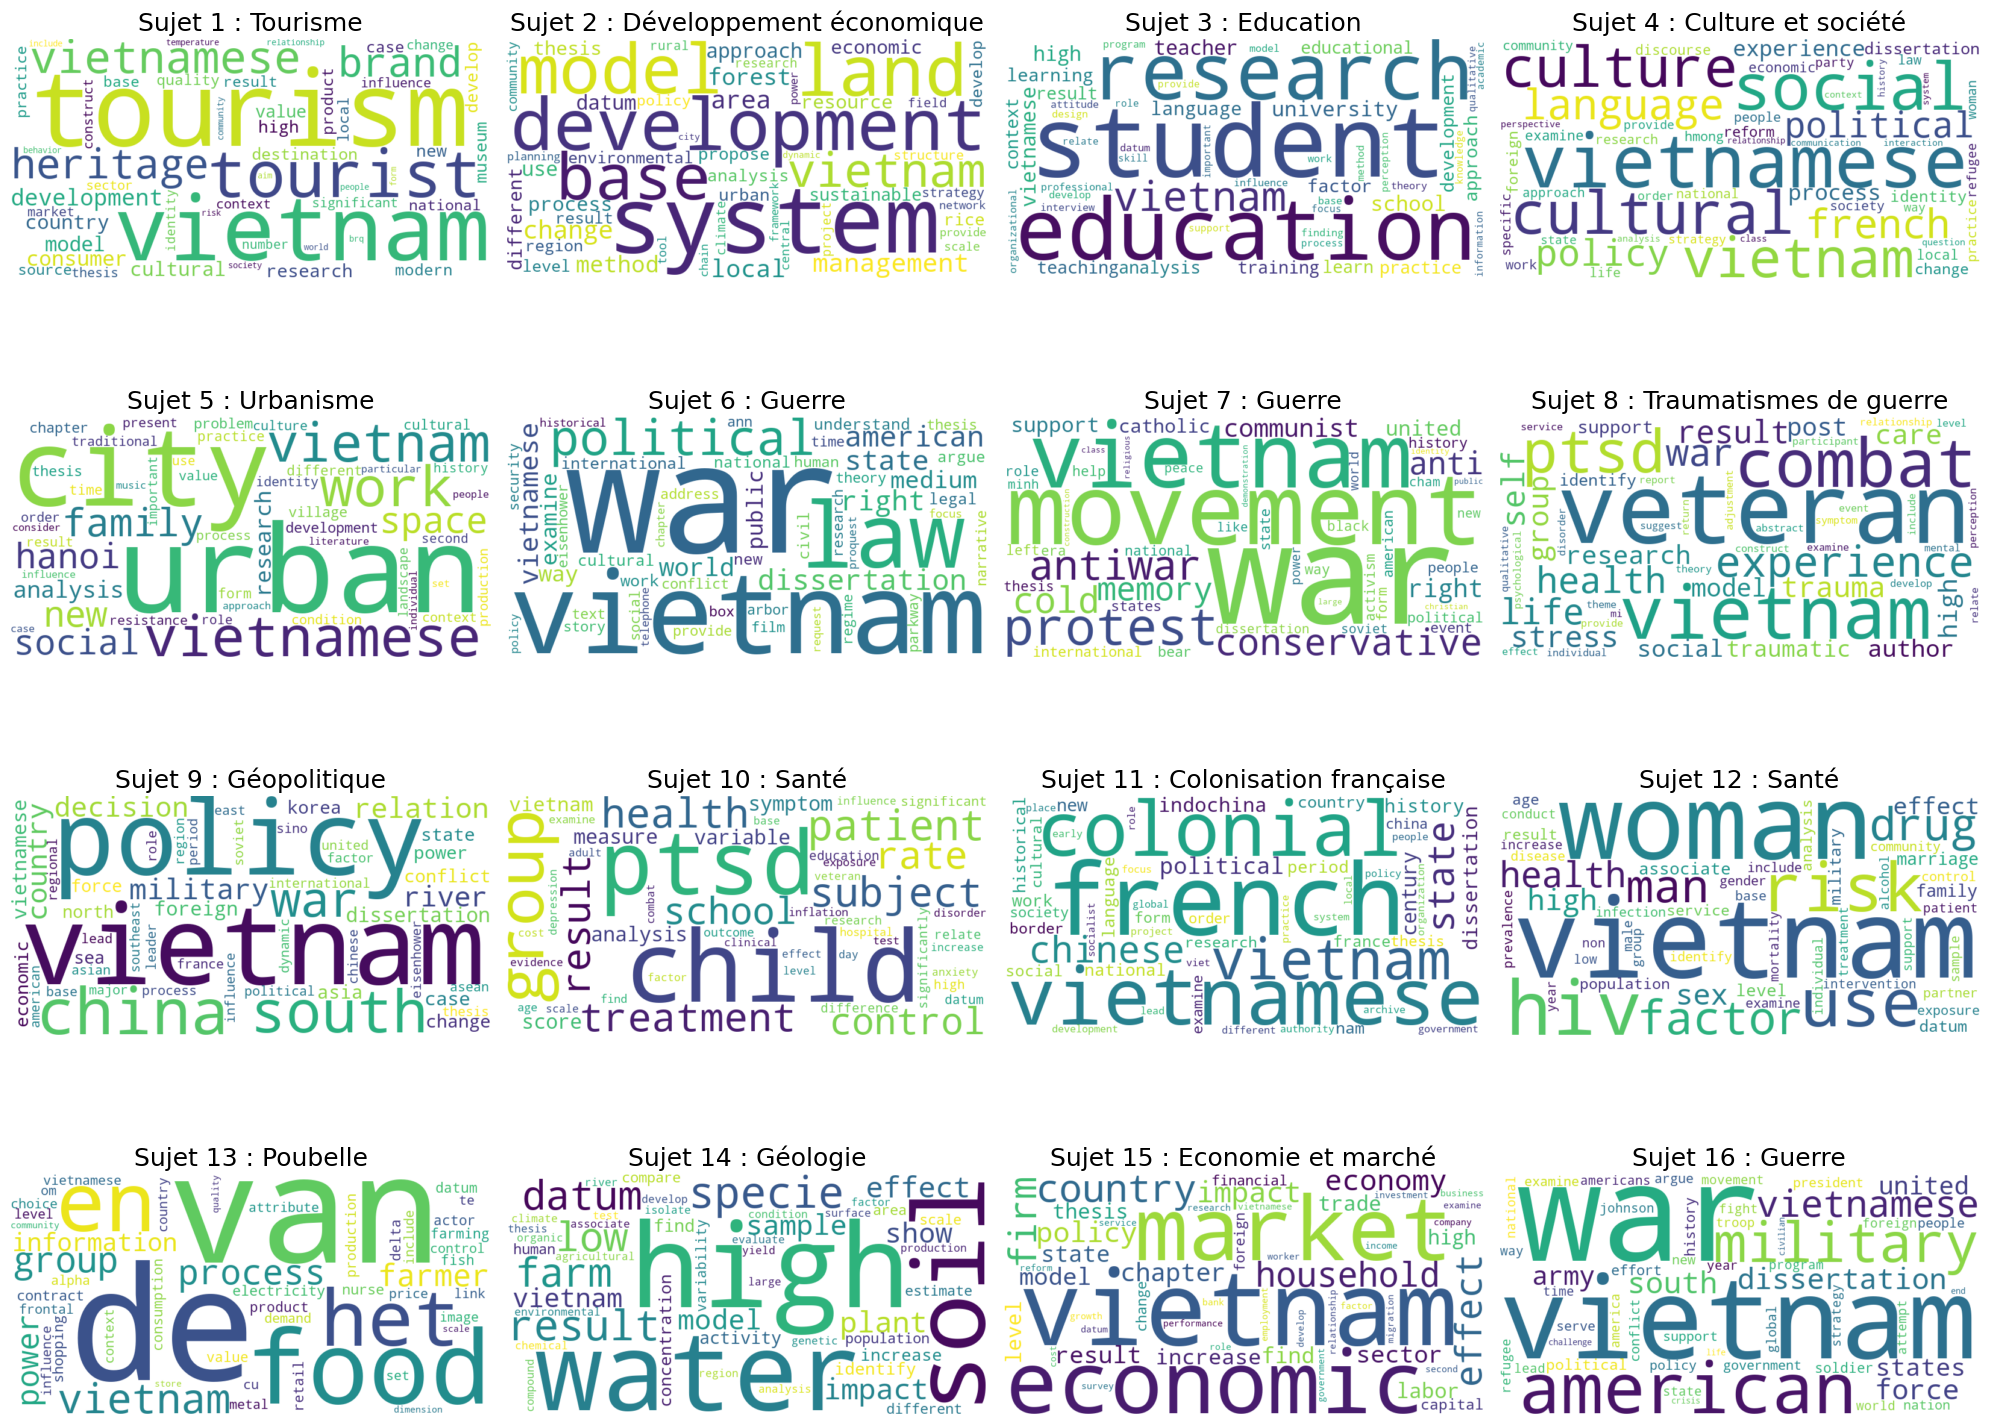

In [95]:
def plot_wordclouds_per_topic_grid(model, feature_names, topic_labels=None, n_top_words=50):
    n_topics = model.n_components
    
    n_cols = math.ceil(math.sqrt(n_topics))
    n_rows = math.ceil(n_topics / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_topics > 1 else [axes]
    
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:]
        top_words = {feature_names[i]: topic[i] for i in top_indices}
        
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white"
        ).generate_from_frequencies(top_words)
        
        ax = axes[topic_idx]
        ax.imshow(wordcloud, interpolation="bilinear")
        ax.axis("off")
        
        # Ici on utilise le label manuel si fourni
        if topic_labels:
            ax.set_title(f"Sujet {topic_idx + 1} : {topic_labels[topic_idx]}", fontsize=18)
    
    for j in range(topic_idx + 1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.savefig("lda.png")
    plt.show()

plot_wordclouds_per_topic_grid(model=lda,
                               feature_names=feature_names,
                               topic_labels=topic_labels_manual,
                               n_top_words=50)

# 4. Vers les graphes

In [96]:
doc_topic_dist = lda.transform(X)  # forme (n_docs, n_topics)

# Topics à garder (supprimer "Poubelle")
topics_to_keep = [i for i in range(lda.n_components) if i != 12]
doc_topic_dist_filtered = doc_topic_dist[:, topics_to_keep]

# Labels correspondants
topic_labels_filtered = {i: topic_labels_manual[i] for i in topics_to_keep}

# Ajouter les probabilités de chaque topic au DataFrame
for idx, topic_idx in enumerate(topics_to_keep):
    df[f'topic_{topic_idx}_prob'] = doc_topic_dist_filtered[:, idx]

# Topic dominant
dominant_topics_idx = doc_topic_dist_filtered.argmax(axis=1)
df['dominant_topic_idx'] = [topics_to_keep[i] for i in dominant_topics_idx]
df['dominant_topic_label'] = [topic_labels_manual[i] for i in df['dominant_topic_idx']]

# Topics pertinents avec seuil ; si vide, prendre le dominant
threshold = 0.2
df['relevant_topics'] = df[[f'topic_{i}_prob' for i in topics_to_keep]].apply(
    lambda row: [
        topic_labels_filtered[i] for i, val in zip(topics_to_keep, row) if val >= threshold
    ] or [topic_labels_filtered[row.argmax()]],  # si vide, prend le dominant
    axis=1
)
df

,title,authors,abstract,date,source,year,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,...,topic_8_prob,topic_9_prob,topic_10_prob,topic_11_prob,topic_13_prob,topic_14_prob,topic_15_prob,dominant_topic_idx,dominant_topic_label,relevant_topics
0,Constitutional protection of Human rights in V...,"Nguyen, Linh Giang (187515689)",The Constitution definitely has an indispensab...,29/06/2015,fr,2015,0.000255,0.000255,0.000255,0.000255,...,0.000255,0.000255,0.069706,0.000255,0.000255,0.000255,0.084927,5,Guerre,[Guerre]
1,Industrial Strategy of the Asian countries in ...,"Nguyen, Binh Duong (151022720)",This thesis examines the key issues in choosin...,01/01/2010,fr,2010,0.000781,0.000781,0.092870,0.000781,...,0.000781,0.118188,0.074871,0.000781,0.000781,0.643062,0.000781,14,Economie et marché,[Economie et marché]
2,The establishment and the operation of foreign...,"Pham, Viet Anh (142793787)",The establishment and the operation of foreign...,01/01/2009,fr,2009,0.010417,0.010417,0.010417,0.010417,...,0.010417,0.010417,0.010417,0.010417,0.010417,0.302749,0.551417,15,Guerre,"[Economie et marché, Guerre]"
3,The political quest for strategic autonomy. Th...,"Lê, Antoine (28231234X)",Much has been written about the relationship b...,30/05/2024,fr,2024,0.000791,0.000791,0.000791,0.000791,...,0.243932,0.000791,0.336107,0.000791,0.000791,0.000791,0.409676,15,Guerre,"[Géopolitique, Colonisation française, Guerre]"
4,Foreign direct investment in Vietnam,"Nguyen, Duc Tho (116118571)",Foreign direct investment in Vietnam,01/01/2005,fr,2005,0.012500,0.012500,0.012500,0.012500,...,0.012500,0.012500,0.012500,0.012500,0.012500,0.812500,0.012500,14,Economie et marché,[Economie et marché]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,The Tay So'n Uprising: Society and rebellion i...,"Dutton, George Edson",This project is an examination of the [special...,2001,us,2001,0.000368,0.000368,0.000368,0.000368,...,0.000368,0.000368,0.719608,0.000368,0.000368,0.000368,0.011838,10,Colonisation française,"[Guerre, Colonisation française]"
2054,Ambiguity of identity: The case of Na Mieu in ...,"Thang, Nguyen Van",This dissertation is a study of how people in ...,2001,us,2001,0.455883,0.000679,0.000679,0.302972,...,0.000679,0.000679,0.000679,0.000679,0.000679,0.232314,0.000679,0,Tourisme,"[Tourisme, Culture et société, Economie et mar..."
2055,Missions and conversions: Creating the Montagn...,"Pearson, Thomas",This dissertation examines the history of cros...,2001,us,2001,0.280276,0.000353,0.000353,0.144914,...,0.000353,0.006637,0.120532,0.000353,0.000353,0.000353,0.241763,0,Tourisme,"[Tourisme, Guerre, Guerre]"
2056,Employment in Vietnam: A gender equal division...,"Alva, Soumya",As developing economies undergo far reaching m...,2001,us,2001,0.000303,0.000303,0.000303,0.025240,...,0.000303,0.000303,0.000303,0.297000,0.000303,0.673816,0.000303,14,Economie et marché,"[Santé, Economie et marché]"


In [97]:
df['relevant_topics'].value_counts()

relevant_topics
[Guerre]                                                        128
[Economie et marché]                                             98
[Urbanisme]                                                      66
[Colonisation française]                                         64
[Santé]                                                          58
                                                               ... 
[Culture et société, Urbanisme, Colonisation française]           1
[Education, Santé, Géologie]                                      1
[Développement économique, Traumatismes de guerre, Géologie]      1
[Culture et société, Guerre, Géopolitique]                        1
[Tourisme, Culture et société, Economie et marché]                1
Name: count, Length: 230, dtype: int64

In [98]:
df['n_relevant_topics'] = df['relevant_topics'].apply(len)

counts = df['n_relevant_topics'].value_counts().sort_index()
print(counts)

n_relevant_topics
1     673
2    1018
3     261
4       5
Name: count, dtype: int64


In [99]:
# Aplatir toutes les listes de relevant_topics en une seule liste
all_relevant = [topic for topics in df['relevant_topics'] for topic in topics]

# Compter les apparitions
topic_appearances = Counter(all_relevant)

# Affichage propre
for topic, count in topic_appearances.items():
    print(f"{topic} : {count} apparitions")

Guerre : 728 apparitions
Economie et marché : 399 apparitions
Géopolitique : 223 apparitions
Colonisation française : 288 apparitions
Tourisme : 122 apparitions
Traumatismes de guerre : 172 apparitions
Education : 261 apparitions
Développement économique : 294 apparitions
Santé : 317 apparitions
Urbanisme : 336 apparitions
Culture et société : 175 apparitions
Géologie : 197 apparitions


Pour Gephi

In [100]:
G = nx.Graph()

# 🔹 Nœuds "thèmes"
for topic in set([t for topics in df['relevant_topics'] for t in topics]):
    G.add_node(
        f"topic::{topic}",
        label=topic,
        type="topic"
    )

# 🔹 Nœuds "thèses" et liens vers les topics
for idx, row in df.iterrows():
    thesis_id = f"thesis::{idx}"  # identifiant unique pour chaque thèse
    G.add_node(
        thesis_id,
        label="",
        #label = str(row['title'])[:50],  # ou autre info pour identifier la thèse
        type="thesis",
        source=row['source']         # fr ou eng
    )
    
    # Ajouter les arêtes vers les topics pertinents
    for topic in row['relevant_topics']:
        G.add_edge(
            thesis_id,
            f"topic::{topic}",
            type="thesis-topic"
        )

#nx.write_gexf(G, "thesis_topic_graph66.gexf")